In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [10]:
# 1. Definir los nombres de las 41 columnas + la etiqueta
# Estos nombres están tomados de kddcup.names
column_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes',
    'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
    'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
    'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label'
]

In [11]:
# 2. Ruta del archivo
file_path = 'archive/kddcup.data_10_percent.gz'

In [12]:
# 3. Cargar el dataset
print("Cargando dataset...")
df = pd.read_csv(file_path, 
                 compression='gzip', 
                 names=column_names,
                 header=None)

Cargando dataset...


In [13]:
# 4. Mostrar información básica
print("\n" + "="*50)
print("INFORMACIÓN BÁSICA DEL DATASET")
print("="*50)

print(f"\nNúmero de registros: {len(df)}")
print(f"Número de columnas: {len(df.columns)}")

print("\n" + "-"*50)
print("PRIMERAS 5 FILAS:")
print("-"*50)
print(df.head())

print("\n" + "-"*50)
print("ÚLTIMAS 5 FILAS:")
print("-"*50)
print(df.tail())

print("\n" + "-"*50)
print("TIPOS DE DATOS POR COLUMNA:")
print("-"*50)
print(df.dtypes)


INFORMACIÓN BÁSICA DEL DATASET

Número de registros: 494021
Número de columnas: 42

--------------------------------------------------
PRIMERAS 5 FILAS:
--------------------------------------------------
   duration protocol_type service flag  src_bytes  dst_bytes  land  \
0         0           tcp    http   SF        181       5450     0   
1         0           tcp    http   SF        239        486     0   
2         0           tcp    http   SF        235       1337     0   
3         0           tcp    http   SF        219       1337     0   
4         0           tcp    http   SF        217       2032     0   

   wrong_fragment  urgent  hot  ...  dst_host_srv_count  \
0               0       0    0  ...                   9   
1               0       0    0  ...                  19   
2               0       0    0  ...                  29   
3               0       0    0  ...                  39   
4               0       0    0  ...                  49   

   dst_host_same_sr

In [14]:
# Continuación del EDA
print("\n" + "="*50)
print("ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
print("="*50)

# Seleccionar solo columnas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(f"\nNúmero de variables numéricas: {len(numeric_cols)}")

# Mostrar estadísticas básicas (solo primeras 10 columnas para no saturar)
print("\nEstadísticas de las primeras 10 variables numéricas:")
print(df[numeric_cols[:10]].describe())

print("\n" + "-"*50)
print("ANÁLISIS DE LA ETIQUETA (LABEL)")
print("-"*50)

# Contar frecuencia de cada tipo de label
label_counts = df['label'].value_counts()
print(f"\nTotal de etiquetas únicas: {len(label_counts)}")
print("\nLas 10 etiquetas más frecuentes:")
print(label_counts.head(10))

print("\n" + "-"*50)
print("CLASIFICACIÓN: NORMAL vs ATAQUE")
print("-"*50)

# Identificar registros normales (contienen 'normal')
normal_count = df[df['label'].str.contains('normal', case=False, na=False)].shape[0]
attack_count = len(df) - normal_count

print(f"\nRegistros NORMALES: {normal_count} ({normal_count/len(df)*100:.2f}%)")
print(f"Registros ATAQUE: {attack_count} ({attack_count/len(df)*100:.2f}%)")

print("\n" + "-"*50)
print("VARIABLES CATEGÓRICAS")
print("-"*50)

# Analizar las 3 variables categóricas
categorical_cols = ['protocol_type', 'service', 'flag']

for col in categorical_cols:
    print(f"\n{col.upper()}:")
    print(f"  Valores únicos: {df[col].nunique()}")
    print(f"  Valores más frecuentes:")
    print(df[col].value_counts().head(5))


ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS

Número de variables numéricas: 38

Estadísticas de las primeras 10 variables numéricas:
            duration     src_bytes     dst_bytes           land  \
count  494021.000000  4.940210e+05  4.940210e+05  494021.000000   
mean       47.979302  3.025610e+03  8.685324e+02       0.000045   
std       707.746472  9.882181e+05  3.304000e+04       0.006673   
min         0.000000  0.000000e+00  0.000000e+00       0.000000   
25%         0.000000  4.500000e+01  0.000000e+00       0.000000   
50%         0.000000  5.200000e+02  0.000000e+00       0.000000   
75%         0.000000  1.032000e+03  0.000000e+00       0.000000   
max     58329.000000  6.933756e+08  5.155468e+06       1.000000   

       wrong_fragment         urgent            hot  num_failed_logins  \
count   494021.000000  494021.000000  494021.000000      494021.000000   
mean         0.006433       0.000014       0.034519           0.000152   
std          0.134805       0.005510


GENERANDO VISUALIZACIONES...
✓ Gráfico 1 guardado: graficos_eda/01_distribucion_clases.png


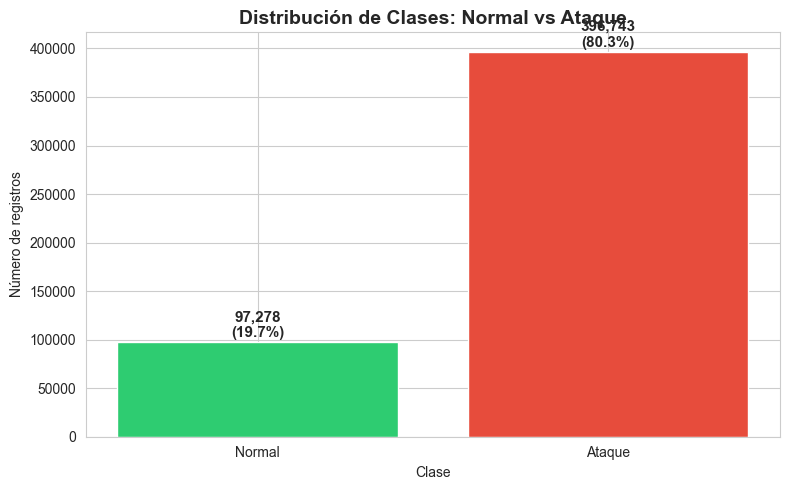

In [18]:
print("\n" + "="*50)
print("GENERANDO VISUALIZACIONES...")
print("="*50)

# Configurar estilo de gráficos
plt.style.use('default')
sns.set_style("whitegrid")

# Crear carpeta para guardar gráficos
if not os.path.exists('graficos_eda'):
    os.makedirs('graficos_eda')

# 1. Gráfico: Distribución de clases (Normal vs Ataque)
plt.figure(figsize=(8, 5))
classes = ['Normal', 'Ataque']
counts = [normal_count, attack_count]
colors = ['#2ecc71', '#e74c3c']
bars = plt.bar(classes, counts, color=colors)
plt.title('Distribución de Clases: Normal vs Ataque', fontsize=14, fontweight='bold')
plt.ylabel('Número de registros')
plt.xlabel('Clase')
# Agregar etiquetas con los valores
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000, 
             f'{count:,}\n({count/len(df)*100:.1f}%)', 
             ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('graficos_eda/01_distribucion_clases.png', dpi=150)
print("✓ Gráfico 1 guardado: graficos_eda/01_distribucion_clases.png")


✓ Gráfico 2 guardado: graficos_eda/02_top_10_ataques.png


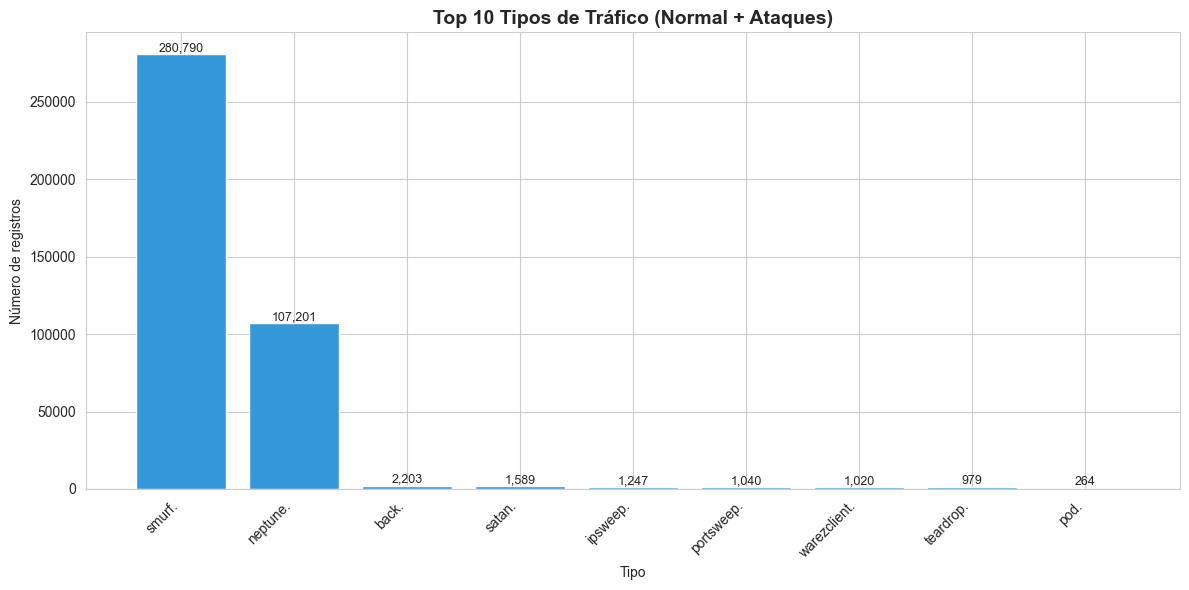

In [19]:
# 2. Gráfico: Top 10 ataques
plt.figure(figsize=(12, 6))
top_attacks = label_counts.head(10)
# Separar 'normal.' para que no aparezca como ataque
attack_counts = top_attacks[top_attacks.index != 'normal.']
colors = ['#3498db' if 'normal' not in idx else '#2ecc71' for idx in attack_counts.index]
bars = plt.bar(range(len(attack_counts)), attack_counts.values, color=colors)
plt.title('Top 10 Tipos de Tráfico (Normal + Ataques)', fontsize=14, fontweight='bold')
plt.xlabel('Tipo')
plt.ylabel('Número de registros')
plt.xticks(range(len(attack_counts)), attack_counts.index, rotation=45, ha='right')
# Agregar etiquetas
for bar, val in zip(bars, attack_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000, 
             f'{val:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('graficos_eda/02_top_10_ataques.png', dpi=150)
print("✓ Gráfico 2 guardado: graficos_eda/02_top_10_ataques.png")


✓ Gráfico 3 guardado: graficos_eda/03_distribucion_protocolos.png


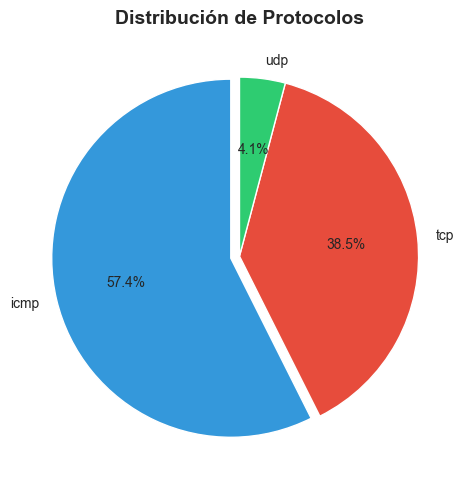

In [20]:
# 3. Gráfico: Distribución de protocol_type
plt.figure(figsize=(8, 5))
protocol_counts = df['protocol_type'].value_counts()
colors = ['#3498db', '#e74c3c', '#2ecc71']
plt.pie(protocol_counts.values, labels=protocol_counts.index, autopct='%1.1f%%', 
        colors=colors, startangle=90, explode=[0.05, 0, 0])
plt.title('Distribución de Protocolos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('graficos_eda/03_distribucion_protocolos.png', dpi=150)
print("✓ Gráfico 3 guardado: graficos_eda/03_distribucion_protocolos.png")


✓ Gráfico 4 guardado: graficos_eda/04_top_10_servicios.png


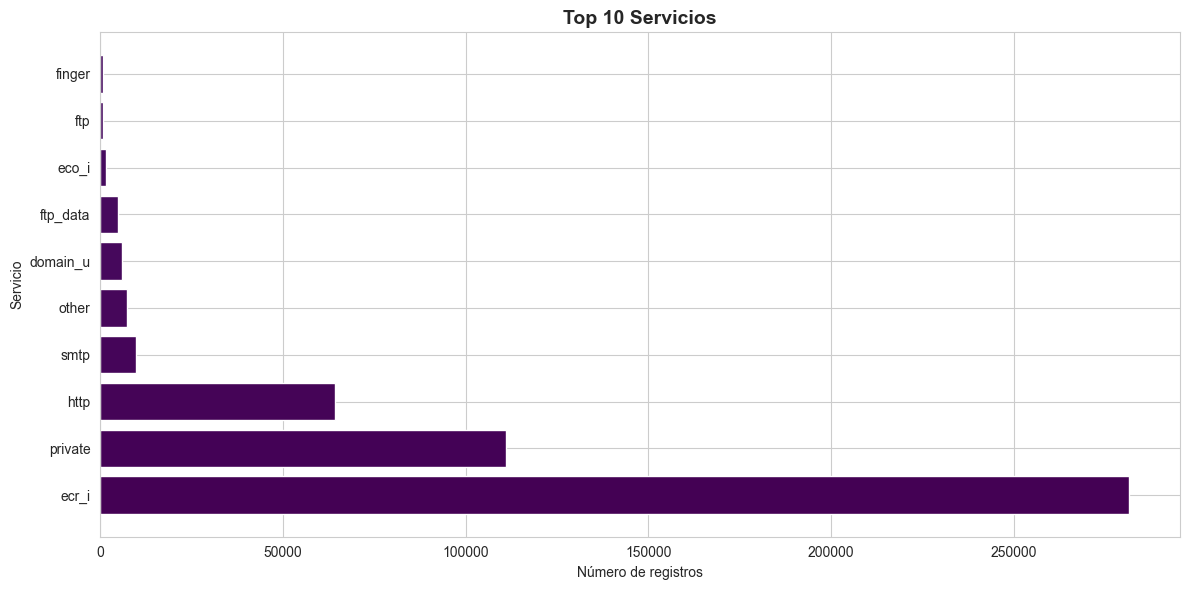

In [21]:
# 4. Gráfico: Top 10 servicios
plt.figure(figsize=(12, 6))
top_services = df['service'].value_counts().head(10)
colors = plt.cm.viridis(range(len(top_services)))
plt.barh(range(len(top_services)), top_services.values, color=colors)
plt.title('Top 10 Servicios', fontsize=14, fontweight='bold')
plt.xlabel('Número de registros')
plt.ylabel('Servicio')
plt.yticks(range(len(top_services)), top_services.index)
plt.tight_layout()
plt.savefig('graficos_eda/04_top_10_servicios.png', dpi=150)
print("✓ Gráfico 4 guardado: graficos_eda/04_top_10_servicios.png")


✓ Gráfico 5 guardado: graficos_eda/05_top_flags.png


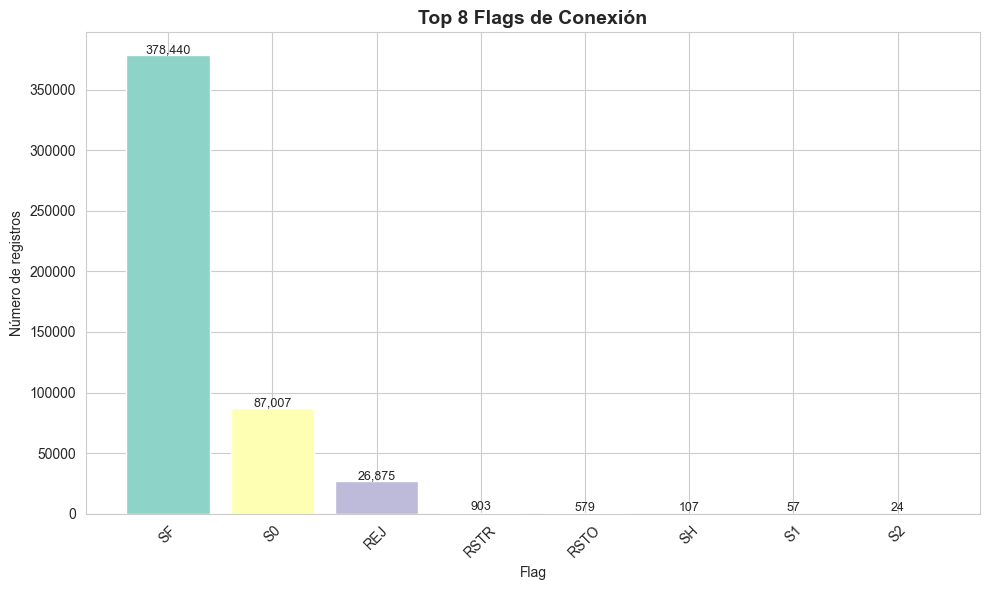

In [22]:
# 5. Gráfico: Distribución de flags
plt.figure(figsize=(10, 6))
top_flags = df['flag'].value_counts().head(8)
colors = plt.cm.Set3(range(len(top_flags)))
bars = plt.bar(range(len(top_flags)), top_flags.values, color=colors)
plt.title('Top 8 Flags de Conexión', fontsize=14, fontweight='bold')
plt.xlabel('Flag')
plt.ylabel('Número de registros')
plt.xticks(range(len(top_flags)), top_flags.index, rotation=45)
for bar, val in zip(bars, top_flags.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000, 
             f'{val:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('graficos_eda/05_top_flags.png', dpi=150)
print("✓ Gráfico 5 guardado: graficos_eda/05_top_flags.png")


✓ Gráfico 6 guardado: graficos_eda/06_histograma_duracion.png

VISUALIZACIONES COMPLETADAS
Los gráficos se guardaron en la carpeta: graficos_eda/


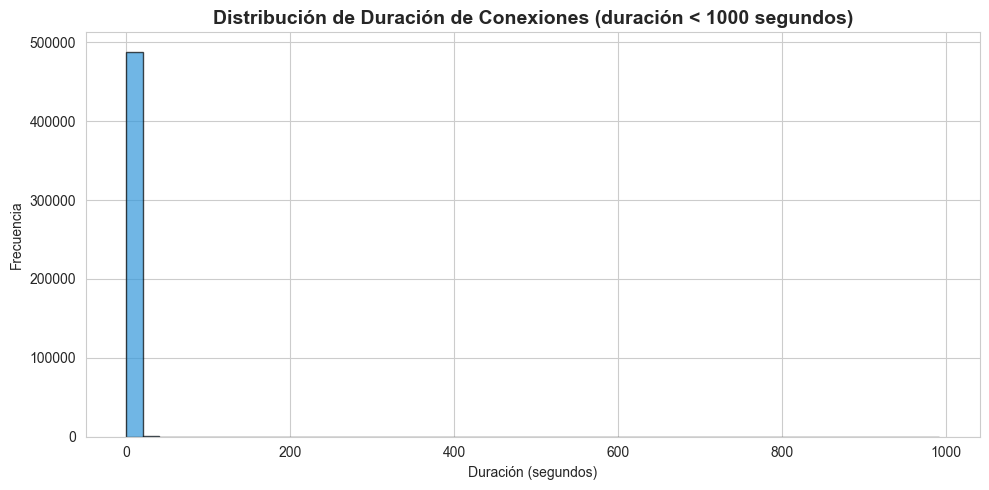

In [23]:
# 6. Histograma de duración (log scale para mejor visualización)
plt.figure(figsize=(10, 5))
plt.hist(df['duration'][df['duration'] < 1000], bins=50, color='#3498db', alpha=0.7, edgecolor='black')
plt.title('Distribución de Duración de Conexiones (duración < 1000 segundos)', fontsize=14, fontweight='bold')
plt.xlabel('Duración (segundos)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('graficos_eda/06_histograma_duracion.png', dpi=150)
print("✓ Gráfico 6 guardado: graficos_eda/06_histograma_duracion.png")

print("\n" + "="*50)
print("VISUALIZACIONES COMPLETADAS")
print("="*50)
print("Los gráficos se guardaron en la carpeta: graficos_eda/")

In [27]:
print("\n" + "="*50)
print("PREPARACIÓN DE DATOS PARA RBM")
print("="*50)

from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')


PREPARACIÓN DE DATOS PARA RBM


In [28]:
# 1. Crear una copia del dataset original
df_clean = df.copy()

In [29]:
# 2. Crear columna binaria: 0 = Normal, 1 = Ataque (para evaluación)
df_clean['is_attack'] = df_clean['label'].apply(lambda x: 0 if 'normal' in str(x).lower() else 1)

print(f"\n✓ Columna 'is_attack' creada:")
print(f"  - Normal (0): {(df_clean['is_attack']==0).sum()}")
print(f"  - Ataque (1): {(df_clean['is_attack']==1).sum()}")



✓ Columna 'is_attack' creada:
  - Normal (0): 97278
  - Ataque (1): 396743


In [31]:
# 3. Codificar variables categóricas (protocol_type, service, flag)
print("\n" + "-"*50)
print("CODIFICACIÓN DE VARIABLES CATEGÓRICAS")
print("-"*50)

# Usar LabelEncoder para cada variable categórica
le_protocol = LabelEncoder()
le_service = LabelEncoder()
le_flag = LabelEncoder()

df_clean['protocol_type_enc'] = le_protocol.fit_transform(df_clean['protocol_type'])
df_clean['service_enc'] = le_service.fit_transform(df_clean['service'])
df_clean['flag_enc'] = le_flag.fit_transform(df_clean['flag'])

print(f"\nprotocol_type: {dict(zip(le_protocol.classes_, range(len(le_protocol.classes_))))}")
print(f"service: {len(le_service.classes_)} valores únicos codificados")
print(f"flag: {len(le_flag.classes_)} valores únicos codificados")



--------------------------------------------------
CODIFICACIÓN DE VARIABLES CATEGÓRICAS
--------------------------------------------------

protocol_type: {'icmp': 0, 'tcp': 1, 'udp': 2}
service: 66 valores únicos codificados
flag: 11 valores únicos codificados


In [32]:
# 4. Seleccionar variables para el modelo
# Excluimos: label original, is_attack (la usaremos solo para evaluación), y las categóricas originales
features_to_drop = ['label', 'is_attack', 'protocol_type', 'service', 'flag']
X = df_clean.drop(columns=features_to_drop)

print(f"\n✓ Variables seleccionadas para el modelo: {len(X.columns)}")
print(f"\nLista de variables:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2}. {col}")


✓ Variables seleccionadas para el modelo: 41

Lista de variables:
   1. duration
   2. src_bytes
   3. dst_bytes
   4. land
   5. wrong_fragment
   6. urgent
   7. hot
   8. num_failed_logins
   9. logged_in
  10. num_compromised
  11. root_shell
  12. su_attempted
  13. num_root
  14. num_file_creations
  15. num_shells
  16. num_access_files
  17. num_outbound_cmds
  18. is_host_login
  19. is_guest_login
  20. count
  21. srv_count
  22. serror_rate
  23. srv_serror_rate
  24. rerror_rate
  25. srv_rerror_rate
  26. same_srv_rate
  27. diff_srv_rate
  28. srv_diff_host_rate
  29. dst_host_count
  30. dst_host_srv_count
  31. dst_host_same_srv_rate
  32. dst_host_diff_srv_rate
  33. dst_host_same_src_port_rate
  34. dst_host_srv_diff_host_rate
  35. dst_host_serror_rate
  36. dst_host_srv_serror_rate
  37. dst_host_rerror_rate
  38. dst_host_srv_rerror_rate
  39. protocol_type_enc
  40. service_enc
  41. flag_enc


In [33]:
# 5. Escalar variables numéricas (para RBM necesitamos valores entre 0 y 1 o normalizados)
print("\n" + "-"*50)
print("ESCALADO DE VARIABLES")
print("-"*50)

# Separar datos normales y ataques (para entrenar RBM solo con normales)
X_normal = X[df_clean['is_attack'] == 0]
X_attack = X[df_clean['is_attack'] == 1]

print(f"\nDatos para entrenamiento RBM (solo normales): {len(X_normal)} registros")
print(f"Datos de prueba (ataques): {len(X_attack)} registros")

# Escalar todas las variables (MinMaxScaler para llevar a rango [0,1] recomendado para RBM)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Ajustar scaler con datos normales (solo normales)
X_normal_scaled = scaler.fit_transform(X_normal)
X_attack_scaled = scaler.transform(X_attack)

# También escalar todo el X para referencia
X_scaled = scaler.transform(X)

print(f"\n✓ Escalado completado (MinMaxScaler, rango [0,1])")
print(f"  - Mínimo después de escalar: {X_scaled.min():.4f}")
print(f"  - Máximo después de escalar: {X_scaled.max():.4f}")


--------------------------------------------------
ESCALADO DE VARIABLES
--------------------------------------------------

Datos para entrenamiento RBM (solo normales): 97278 registros
Datos de prueba (ataques): 396743 registros

✓ Escalado completado (MinMaxScaler, rango [0,1])
  - Mínimo después de escalar: 0.0000
  - Máximo después de escalar: 315.9435


In [34]:
# 6. Guardar datasets procesados
print("\n" + "-"*50)
print("GUARDANDO DATASETS PROCESADOS")
print("-"*50)

# Guardar en formato numpy para usar con RBM
np.save('data_normal_scaled.npy', X_normal_scaled)
np.save('data_attack_scaled.npy', X_attack_scaled)
np.save('data_all_scaled.npy', X_scaled)

# Guardar también en CSV para referencia
pd.DataFrame(X_normal_scaled).to_csv('data_normal_scaled.csv', index=False)
pd.DataFrame(X_attack_scaled).to_csv('data_attack_scaled.csv', index=False)

# Guardar información de los scalers y codificadores
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump({'protocol': le_protocol, 'service': le_service, 'flag': le_flag}, f)

print(f"\n✓ Datos guardados:")
print(f"  - data_normal_scaled.npy: {X_normal_scaled.shape}")
print(f"  - data_attack_scaled.npy: {X_attack_scaled.shape}")
print(f"  - data_all_scaled.npy: {X_scaled.shape}")
print(f"  - scaler.pkl (para futuras predicciones)")
print(f"  - label_encoders.pkl")


--------------------------------------------------
GUARDANDO DATASETS PROCESADOS
--------------------------------------------------

✓ Datos guardados:
  - data_normal_scaled.npy: (97278, 41)
  - data_attack_scaled.npy: (396743, 41)
  - data_all_scaled.npy: (494021, 41)
  - scaler.pkl (para futuras predicciones)
  - label_encoders.pkl


In [35]:
# 7. Estadísticas finales
print("\n" + "="*50)
print("RESUMEN FINAL - DATOS LISTOS PARA RBM")
print("="*50)

print(f"""
Variables de entrada: {X.shape[1]}
  - Originales: 41 features
  - Codificadas: +3 features categóricas codificadas
  - Total para RBM: {X.shape[1]} features

Distribución:
  - Entrenamiento (solo normales): {len(X_normal):,} registros
  - Prueba (ataques): {len(X_attack):,} registros

Archivos generados:
  ✓ data_normal_scaled.npy  -> Para entrenar RBM
  ✓ data_attack_scaled.npy  -> Para evaluar detección de anomalías
  ✓ scaler.pkl              -> Para escalar nuevos datos
  ✓ label_encoders.pkl      -> Para codificar nuevas muestras
""")

print("\n✅ PREPARACIÓN COMPLETADA. LISTO PARA IMPLEMENTAR RBM.")


RESUMEN FINAL - DATOS LISTOS PARA RBM

Variables de entrada: 41
  - Originales: 41 features
  - Codificadas: +3 features categóricas codificadas
  - Total para RBM: 41 features

Distribución:
  - Entrenamiento (solo normales): 97,278 registros
  - Prueba (ataques): 396,743 registros

Archivos generados:
  ✓ data_normal_scaled.npy  -> Para entrenar RBM
  ✓ data_attack_scaled.npy  -> Para evaluar detección de anomalías
  ✓ scaler.pkl              -> Para escalar nuevos datos
  ✓ label_encoders.pkl      -> Para codificar nuevas muestras


✅ PREPARACIÓN COMPLETADA. LISTO PARA IMPLEMENTAR RBM.
